# LGD model and term structure

Completed-workout LGD is modelled on a bounded scale and projected for each possible future default month.

In [1]:
from pathlib import Path
import json
import sqlite3
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import roc_auc_score, brier_score_loss, mean_absolute_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

ROOT = Path.cwd().resolve()
if not (ROOT / "config").exists():
    ROOT = ROOT.parent
DB = ROOT / "database" / "ifrs9_ecl.sqlite3"

def query(sql):
    with sqlite3.connect(DB) as connection:
        return pd.read_sql_query(sql, connection)

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
plt.rcParams["figure.figsize"] = (9, 4)

Development

Target: discounted workout LGD.

Features: LTV, EAD, property value, location, property type, occupancy, modification, HPI, unemployment, insurance and loan age.

Split: first 80% of completed defaults by date for development and last 20% for out-of-time testing.

Method: logit-transform LGD, fit regularised ridge regression and apply the inverse-logit transformation.

Tests: MAE, RMSE, R-squared and observed versus predicted LGD.

In [2]:
query('select * from lgd_model_metrics')

,sample,rows,mae,rmse,r_squared,observed_lgd,predicted_lgd,median_benchmark_mae,method
0,development,293,0.0639,0.1241,0.3187,0.1055,0.0735,0.0774,logit-transformed bounded ridge regression
1,out_of_time,22,0.0456,0.0628,-0.5666,0.0550,0.0614,0.0412,logit-transformed bounded ridge regression


In [3]:
lgd_data = query('select * from lgd_development_sample where completed_workout=1 and workout_lgd is not null and ead_at_default>0')
lgd_data['default_date'] = pd.to_datetime(lgd_data.default_date)
lgd_numeric = ['estimated_ltv_at_default','ead_at_default','original_property_value','unemployment_rate','hpi_growth_yoy','mortgage_insurance_percentage','loan_age_at_default']
lgd_categorical = ['property_state','property_type','occupancy_status','modification_at_default']
cutoff = lgd_data.default_date.sort_values().iloc[int(len(lgd_data)*.8)]
lgd_development = lgd_data[lgd_data.default_date<cutoff]
lgd_test = lgd_data[lgd_data.default_date>=cutoff]
lgd_prepare = ColumnTransformer([
 ('numeric',Pipeline([('impute',SimpleImputer(strategy='median')),('scale',StandardScaler())]),lgd_numeric),
 ('categorical',Pipeline([('impute',SimpleImputer(strategy='most_frequent')),('onehot',OneHotEncoder(handle_unknown='ignore'))]),lgd_categorical)])
y = np.log(lgd_development.workout_lgd.clip(.005,.995)/(1-lgd_development.workout_lgd.clip(.005,.995)))
notebook_lgd = Pipeline([('prepare',lgd_prepare),('ridge',Ridge(alpha=5))]).fit(lgd_development[lgd_numeric+lgd_categorical],y)
prediction = 1/(1+np.exp(-notebook_lgd.predict(lgd_test[lgd_numeric+lgd_categorical])))
{'development_rows':len(lgd_development),'out_of_time_rows':len(lgd_test),
 'out_of_time_mae':mean_absolute_error(lgd_test.workout_lgd,prediction),
 'median_benchmark_mae':mean_absolute_error(lgd_test.workout_lgd,np.repeat(lgd_development.workout_lgd.median(),len(lgd_test)))}

{'development_rows': 249,
 'out_of_time_rows': 66,
 'out_of_time_mae': 0.06468781883997383,
 'median_benchmark_mae': 0.05557846641303694}

Text(0.5, 1.0, 'Stage 2 LGD term structure')

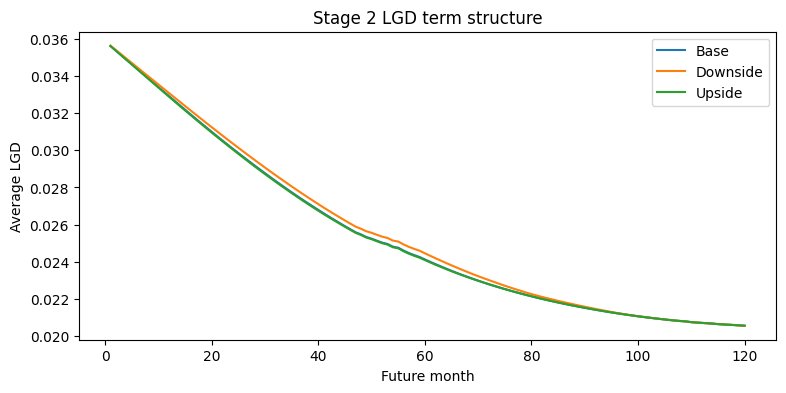

In [4]:
lgd_term = query("select * from lgd_term_structure where stage=2 and future_month<=120")
for name, data in lgd_term.groupby('scenario'):
    plt.plot(data.future_month, data.lgd, label=name)
plt.xlabel('Future month'); plt.ylabel('Average LGD'); plt.legend(); plt.title('Stage 2 LGD term structure')

The fitted regression supplies the Base conditional LGD. Scenario HPI changes collateral value and the collateral shortfall floor. Output is LGD conditional on default in month t.